## Exploratory Data Analysis for extracted NasaDem features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nm_df = pd.read_csv("../data/nasadem_features_training.csv")
nm_df.head()

,Unnamed: 0,elevation,Latitude,Longitude,Sample Date
0,0,167.155040,-28.760833,17.730278,02-01-2011
1,1,1521.251493,-26.861111,28.884722,03-01-2011
2,2,1471.379902,-26.450000,28.085833,03-01-2011
3,3,1342.659998,-27.671111,27.236944,03-01-2011
4,4,1355.983661,-27.356667,27.286389,03-01-2011


Can drop unnamed column later, was used for id.

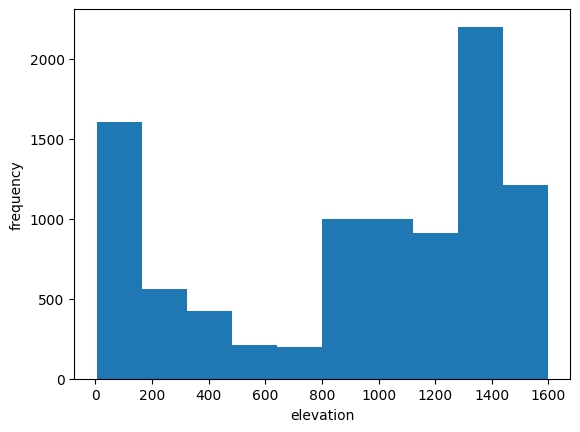

In [4]:
plt.hist(nm_df['elevation'])
plt.xlabel('elevation')
plt.ylabel('frequency')
plt.show()

Data is quite skewed, definetly needs scaling for SVM, maybe a log transformation too.

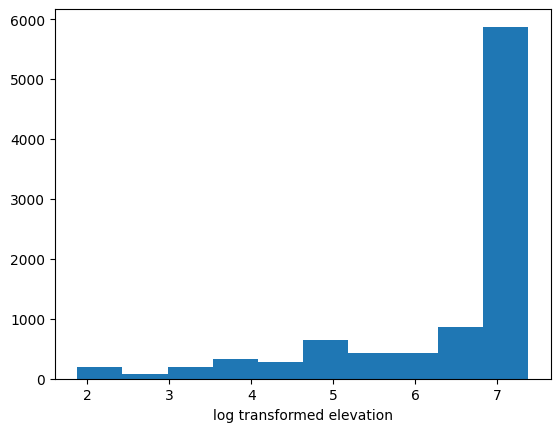

In [6]:
plt.hist(np.log1p(nm_df['elevation']))
plt.xlabel('log transformed elevation')
plt.show()

Best to stick to standard scaling, super left skewed if log transformed.

In [7]:
nm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   9319 non-null   int64  
 1   elevation    9319 non-null   float64
 2   Latitude     9319 non-null   float64
 3   Longitude    9319 non-null   float64
 4   Sample Date  9319 non-null   object 
dtypes: float64(3), int64(1), object(1)
memory usage: 364.2+ KB


In [8]:
nm_df.describe()

,Unnamed: 0,elevation,Latitude,Longitude
count,9319.000000,9319.000000,9319.000000,9319.000000
mean,4659.000000,912.703348,-28.474988,26.868414
std,2690.307913,514.992034,2.760282,3.535164
min,0.000000,5.545029,-34.405833,17.730278
25%,2329.500000,388.516336,-30.160091,26.126667
50%,4659.000000,1083.049521,-28.058889,27.409060
75%,6988.500000,1320.711972,-26.861111,29.245556
max,9318.000000,1598.033353,-22.225556,32.325000


Check feature importance for elevation, maybe running RFECV